# 01 — The ruler

**Concept:** recall@k, nDCG@k, and the paired bootstrap. \
**Prediction:** none — this notebook builds the instrument the other five use.

Every later notebook makes a claim of the form *"method B beats method A by Δ, and
that difference survives resampling."* Before any of those claims can mean anything,
the ruler itself has to be trustworthy. So this notebook does something the others
deliberately don't: it runs on **controlled data with known ground truth**, not on
NFCorpus. You can only validate a ruler against lengths you already know.

Two lessons live here, and both are places where tutorial eval code silently goes wrong:

1. **Undefined is `None`, never `0.0`.** A query with no relevant documents has no
   recall — averaging in a zero understates every aggregate, and the bug is invisible
   because the number still looks like a number.
2. **Two overlapping confidence intervals do not mean "no difference."** Comparing
   systems with independent CIs throws away the pairing — both systems face the *same*
   queries, so per-query difficulty is a shared nuisance term you can cancel.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from ragexp.metrics import (
    recall_at_k, ndcg_at_k, mean_ignoring_none,
    paired_bootstrap, independent_ci,
)

## Recall@k — a set metric

Recall@k asks one question: *what fraction of the relevant documents made it into the
top k?* It does not care about order inside the top k — and that blindness is a
feature we will lean on hard in notebook 04.

In [2]:
relevant = ["a", "b", "c", "d"]

print("half found:   ", recall_at_k(["a", "b", "x", "y"], relevant, k=4))
print("all found:    ", recall_at_k(["d", "c", "b", "a"], relevant, k=4))

# The set-metric property: reordering inside the top-k changes nothing.
r1 = recall_at_k(["a", "b", "x"], relevant, k=2)
r2 = recall_at_k(["b", "a", "x"], relevant, k=2)
print("reordered top-k, same recall:", r1 == r2)

half found:    0.5
all found:     1.0
reordered top-k, same recall: True


## Lesson 1 — undefined is `None`, never `0.0`

Suppose you score a run over 100 queries, but only 60 of them actually have judged
relevant documents (this is the norm, not the exception: NFCorpus ships 3,237 queries
of which only 323 carry test judgments). For the other 40, recall is **undefined** —
there is nothing to find.

Watch what happens if evaluation code writes those as `0.0` instead:

In [3]:
rng = np.random.default_rng(0)

# 60 defined queries with a true mean recall of ~0.5; 40 undefined queries.
defined = list(np.clip(rng.normal(0.5, 0.15, size=60), 0, 1))
scores = defined + [None] * 40

correct = mean_ignoring_none(scores)
zero_poisoned = np.mean([s if s is not None else 0.0 for s in scores])

print(f"correct mean (None dropped):  {correct:.3f}")
print(f"zero-poisoned mean:           {zero_poisoned:.3f}")
print(f"silent understatement:        {correct - zero_poisoned:.3f} "
      f"({(correct - zero_poisoned) / correct:.0%} of the true score)")

correct mean (None dropped):  0.512
zero-poisoned mean:           0.307
silent understatement:        0.205 (40% of the true score)


A 40% understatement, and nothing crashed. The poisoned number is stable, plausible,
and reproducible — every property people use as a proxy for "correct." This is why
every function in `ragexp.metrics` returns `None` for undefined and why
`mean_ignoring_none` exists. It is also why `data.load_nfcorpus()` drops unjudged
queries at load time: the query count you see is the query count you score.

## nDCG@k — the order-sensitive complement

recall@k can't see order; nDCG@k exists to see exactly that. It discounts each
document's graded relevance by its rank and normalizes by the best achievable ordering,
so a perfect ranking scores 1.0. Reporting both metrics is not redundant — they
disagree precisely when a method reorders without changing membership.

In [4]:
grades = {"a": 2, "b": 1}  # graded relevance, like NFCorpus (1s and 2s)

perfect = ndcg_at_k(["a", "b", "x"], grades, k=3)
swapped = ndcg_at_k(["b", "a", "x"], grades, k=3)
print(f"best doc first:  nDCG = {perfect:.3f}")
print(f"docs swapped:    nDCG = {swapped:.3f}   <- same set, lower score")

recall_same = (recall_at_k(["a", "b", "x"], ["a", "b"], k=3),
               recall_at_k(["b", "a", "x"], ["a", "b"], k=3))
print(f"recall@3 for both orders: {recall_same}  <- recall is blind to the swap")

# And the same undefined rule applies: no positive grades -> None, not 0.0.
print("no relevant docs ->", ndcg_at_k(["x", "y"], {}, k=2))

best doc first:  nDCG = 1.000
docs swapped:    nDCG = 0.797   <- same set, lower score
recall@3 for both orders: (1.0, 1.0)  <- recall is blind to the swap
no relevant docs -> None


## Lesson 2 — paired beats independent, on the *same* data

Here is the setup every retrieval comparison actually has: two systems, scored on the
**same queries**. Queries differ wildly in difficulty — some have 3 relevant docs, some
40; some queries are easy for any method. That difficulty is a *shared* nuisance term.

- The **independent** approach bootstraps each system's mean separately and eyeballs
  whether the CIs overlap. Query difficulty inflates both intervals.
- The **paired** approach bootstraps the per-query *difference*. Subtracting cancels
  the shared difficulty, leaving only the signal plus per-system noise.

We simulate 323 queries (NFCorpus-sized) with a known truth: system B is better than
system A by exactly **+0.03**, and per-query difficulty varies far more than that.

In [5]:
rng = np.random.default_rng(42)
n_queries = 323
TRUE_DELTA = 0.03

difficulty = np.clip(rng.normal(0.45, 0.20, size=n_queries), 0.02, 0.98)
noise = lambda: rng.normal(0, 0.05, size=n_queries)

scores_a = list(np.clip(difficulty + noise(), 0, 1))
scores_b = list(np.clip(difficulty + TRUE_DELTA + noise(), 0, 1))

mean_a, ci_a = independent_ci(scores_a)
mean_b, ci_b = independent_ci(scores_b)
delta, ci_d, p = paired_bootstrap(scores_a, scores_b)

overlap = ci_a[1] > ci_b[0]
print(f"system A: {mean_a:.3f}  95% CI [{ci_a[0]:.3f}, {ci_a[1]:.3f}]")
print(f"system B: {mean_b:.3f}  95% CI [{ci_b[0]:.3f}, {ci_b[1]:.3f}]")
print(f"independent CIs overlap: {overlap}")
print()
print(f"paired delta (B - A): {delta:+.4f}  95% CI [{ci_d[0]:+.4f}, {ci_d[1]:+.4f}]  p = {p:.4f}")
print(f"true delta:           {TRUE_DELTA:+.4f}")

system A: 0.445  95% CI [0.425, 0.466]
system B: 0.475  95% CI [0.454, 0.496]
independent CIs overlap: True

paired delta (B - A): +0.0296  95% CI [+0.0214, +0.0377]  p = 0.0000
true delta:           +0.0300


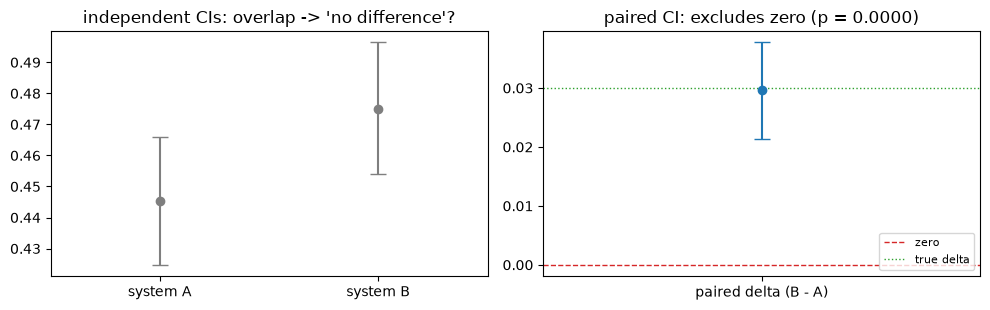

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.2), sharey=False)

ax1.errorbar([0, 1], [mean_a, mean_b],
             yerr=[[mean_a - ci_a[0], mean_b - ci_b[0]],
                   [ci_a[1] - mean_a, ci_b[1] - mean_b]],
             fmt="o", capsize=6, color="tab:gray")
ax1.set_xticks([0, 1], ["system A", "system B"])
ax1.set_xlim(-0.5, 1.5)
ax1.set_title("independent CIs: overlap -> 'no difference'?")

ax2.errorbar([0], [delta], yerr=[[delta - ci_d[0]], [ci_d[1] - delta]],
             fmt="o", capsize=6, color="tab:blue")
ax2.axhline(0, color="tab:red", lw=1, ls="--", label="zero")
ax2.axhline(TRUE_DELTA, color="tab:green", lw=1, ls=":", label="true delta")
ax2.set_xticks([0], ["paired delta (B - A)"])
ax2.set_xlim(-0.5, 0.5)
ax2.legend(loc="lower right", fontsize=8)
ax2.set_title(f"paired CI: excludes zero (p = {p:.4f})")

plt.tight_layout()
plt.show()

Same 323 queries, same scores, two verdicts. The independent CIs overlap — an
eyeball test says "no difference." The paired bootstrap recovers the true +0.03 with a
CI that excludes zero and p ≈ 0. Non-overlapping independent CIs are a *sufficient*
condition for a real difference, but nowhere near *necessary* — and retrieval deltas
in practice are usually the size of this one, not ten times it.

**Every comparison in notebooks 02–06 therefore uses `paired_bootstrap` on the same
323 queries.** When a later notebook says "no significant difference," that claim is
made with the sensitive instrument, not the blunt one.

## What goes in LESSONS.md

| what | number | verdict | lesson |
|---|---|---|---|
| zero-poisoning undefined queries (40/100 undefined) | mean understated ~40% | silent bug | undefined is `None`, never `0.0`; drop, don't zero |
| paired vs independent bootstrap, same data, true Δ=+0.03 | independent CIs overlap; paired p ≈ 0 | instrument choice changes the verdict | compare systems with the paired bootstrap; CI-overlap eyeballing is a weaker test |

No prediction was at stake here — the instrument is now calibrated against known truth.
Next: notebook 02 sets the dense baseline it will measure.